# Blockchain ANN Recommendation Engine
This notebook performs end-to-end data processing and modeling to predict protocol desirability and rank chains for acquisition.

## 1. Initial Setup & Installs

In [112]:
# @title
!pip install tensorflow
!pip install pyspark
!pip install requests
!pip install plotly
!pip install findspark
!pip install keras
!pip install numpy
!pip install pandas
!pip install keras-tuner -q

## 2. Proper PySpark Setup in Google Colab

To ensure a stable PySpark environment in Google Colab, it's often beneficial to use a specific, well-tested combination of Java and PySpark versions. This setup will uninstall any conflicting versions and install `OpenJDK 8` and `PySpark 3.5.1`, which are known to work reliably.

Here are the steps:
1.  **Install Java & PySpark**: Remove existing PySpark, install `OpenJDK 8`, and then `PySpark 3.5.1`.
2.  **Set Environment Variables**: Correctly set `JAVA_HOME` and `SPARK_HOME`.
3.  **Initialize `findspark`**: Allow PySpark to locate the Spark installation.
4.  **Create `SparkSession`**: Initialize the SparkSession with essential configurations.

In [113]:
# 1. Install Java & PySpark

# Uninstall existing pyspark (if any) and install a specific stable version
!pip uninstall -y pyspark

# Install OpenJDK 8 (a stable version for Spark)
!apt-get update && apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Install a stable pyspark version compatible with OpenJDK 8
!pip install pyspark==3.5.1

Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1
Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
  Using cached pyspark-3.5.1-py2.py3-none-any.whl
ERROR: pip's dependency resol

In [114]:
# 2. Set Environment Variables and Initialize findspark

import os
import findspark

# Set JAVA_HOME to the path of the installed OpenJDK 8
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

# Set SPARK_HOME. findspark will find it after pyspark installation.
spark_home_path = findspark.find()
os.environ["SPARK_HOME"] = spark_home_path

# Initialize findspark
findspark.init()

print(f"JAVA_HOME set to: {os.environ.get('JAVA_HOME')}")
print(f"SPARK_HOME set to: {os.environ.get('SPARK_HOME')}")

JAVA_HOME set to: /usr/lib/jvm/java-8-openjdk-amd64
SPARK_HOME set to: /usr/local/lib/python3.13/dist-packages/pyspark


## 3. Core Imports

In [115]:
import tensorflow as tf
import requests
import os
import json
import findspark
import plotly.express as px
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.functions import col, when, regexp_replace, split
from tensorflow import keras
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import tempfile
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from tensorflow.keras import layers, callbacks
import keras_tuner as kt
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras import regularizers

## 4. Data Loading & Initial Preprocessing

In [116]:
# Consolidated and Optimized Spark Session Initialization
warehouse_dir = tempfile.TemporaryDirectory().name
local_dir = tempfile.TemporaryDirectory().name

spark = SparkSession.builder \
    .appName("BlockchainANN") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.warehouse.dir", warehouse_dir) \
    .config("spark.local.dir", local_dir) \
    .getOrCreate()

# Load Data
url = "https://raw.githubusercontent.com/ConorsCode/open-defi-data/main/data/by-chain.json"
raw_data = requests.get(url).json()

# Here we declare the chain from which this data originates and it;s source URL.
chains = "'Ethereum', 'Solana', 'Moonbeam', 'Moonriver', 'Terra'"
# The original URL was a repository link, which returns HTML.
# To fetch raw data (like JSON or CSV) from a GitHub repository,
# you need to use the 'raw.githubusercontent.com' domain
# and specify the full path to the file.

# Define Schema
schema = StructType([
    StructField("chain", StringType(), True),
    StructField("protocolTvlUsd", DoubleType(), True),
    StructField("protocolCount", LongType(), True),
    StructField("poolCount", LongType(), True),
    StructField("poolTvlUsd", DoubleType(), True)
])

# Prepare data types for Spark
prepared_data = []
for row in raw_data:
    new_row = {k: (float(v) if isinstance(v, (int, float)) and k.endswith('Usd') else v) for k, v in row.items()}
    prepared_data.append(new_row)

df = spark.createDataFrame(prepared_data, schema=schema)
df = df.toDF(*[c.lower() for c in df.columns])
df = df.fillna(0)

# Standardization of strings
df = df.withColumn("chain", F.trim(F.lower(F.col("chain"))))

# The code block removes all duplicate rows from the data set.
df.dropDuplicates().show()

print("Spark Preprocessing Complete with optimized configuration.")
display(df.limit(5).toPandas())

+---------------+--------------------+-------------+---------+------------+
|          chain|      protocoltvlusd|protocolcount|poolcount|  pooltvlusd|
+---------------+--------------------+-------------+---------+------------+
|        vesting| 7.569215181673616E9|           33|        0|         0.0|
|         europa|   176866.0583266462|            5|        0|         0.0|
|       wanchain|   2680089.824475578|            9|        0|         0.0|
|         newton|   329018.0087435597|            1|        0|         0.0|
|      bot chain|3.1503546905598894E7|            2|        0|         0.0|
|      okexchain|  1619126.6824452656|           34|        0|         0.0|
|       celestia|    287820.651894825|            4|        0|         0.0|
|       movement|  3783968.3981874646|            8|        0|         0.0|
|         secret|  1179395.2264447296|            9|        0|         0.0|
|           doma|   926074.5490085502|            2|        0|         0.0|
|babylon gen

,chain,protocoltvlusd,protocolcount,poolcount,pooltvlusd
0,ethereum,2.826584e+11,1835,5180,1.221578e+11
1,bitcoin,1.470309e+11,163,3,1.968004e+08
2,binance,4.097148e+10,1106,0,0.000000e+00
3,borrowed,3.056809e+10,631,0,0.000000e+00
4,solana,2.837748e+10,441,2959,1.045139e+10


In [117]:
df.printSchema()

root
 |-- chain: string (nullable = true)
 |-- protocoltvlusd: double (nullable = false)
 |-- protocolcount: long (nullable = true)
 |-- poolcount: long (nullable = true)
 |-- pooltvlusd: double (nullable = false)



In [118]:
df = df.toDF(*[c.lower().replace(" ", "_") for c in df.columns])

In [119]:
# Select only the numeric columns within the dataset.
numeric_columns = [cols for cols, t in df.dtypes if t in ("int", "bigint", "double", "float", "long")]

# Compute the mean values for all numeric columns in one pass.
means = df.select([F.mean(cols).alias(cols) for cols in numeric_columns]).collect()[0].asDict()

# Fill all null values with the columnar mean value.
df = df.fillna(means)

In [120]:
# This code block ensures that all numeric columns in the dataset have consistent double dtype values.
for col_name in numeric_columns:
    df = df.withColumn(col_name, F.col(col_name).cast("double"))

In [121]:
# Standardize categorical columns. Remove excess whitespace.
df = df.withColumn("chain", F.trim(F.lower(F.col("chain"))))

In [122]:
df = df.repartition("chain")

In [123]:
print("\n--- Descriptive Statistics for Overall Dataset ---\n")

# Mean for numeric columns
print("Mean values:")
mean_values = df.select([F.mean(col_name).alias(col_name) for col_name in numeric_columns]).collect()[0].asDict()
for col_name, value in mean_values.items():
    print(f"  {col_name}: {value:.4f}")

# Median for numeric columns (using approximate quantile)
print("\nMedian values (approximate):")
for col_name in numeric_columns:
    median_value = df.approxQuantile(col_name, [0.5], 0.01)[0]
    print(f"  {col_name}: {median_value:.4f}")

# Mode for numeric columns
print("\nMode for numeric columns (most frequent value):")
for col_name in numeric_columns:
    mode_df = df.groupBy(col_name).count().orderBy(F.desc("count"))
    if mode_df.count() > 0:
        mode_value = mode_df.first()[col_name]
        print(f"  {col_name}: {mode_value}")
    else:
        print(f"  {col_name}: No mode found (empty or all unique values)")

# Mode for the 'chain' categorical column
print("\nMode for 'chain' (categorical) column:")
mode_chain_df = df.groupBy('chain').count().orderBy(F.desc("count"))
if mode_chain_df.count() > 0:
    mode_chain_value = mode_chain_df.first()['chain']
    print(f"  chain: {mode_chain_value}")
else:
    print("  chain: No mode found (empty or all unique values)")


--- Descriptive Statistics for Overall Dataset ---

Mean values:
  protocoltvlusd: 1219122736.9930
  protocolcount: 32.7519
  poolcount: 32.9089
  pooltvlusd: 384626060.8857

Median values (approximate):
  protocoltvlusd: 131969.8095
  protocolcount: 3.0000
  poolcount: 0.0000
  pooltvlusd: 0.0000

Mode for numeric columns (most frequent value):
  protocoltvlusd: 0.0
  protocolcount: 1.0
  poolcount: 0.0
  pooltvlusd: 0.0

Mode for 'chain' (categorical) column:
  chain: zksync era


## 5. Feature Engineering & Data Preparation for TensorFlow

In [124]:
# Feature Engineering Pipeline

# 1. Encode Categorical Features (chain)
# Use StringIndexer to convert string categories to numerical indices
string_indexer = StringIndexer(inputCol="chain", outputCol="chain_index", handleInvalid="keep")

# Use OneHotEncoder to convert numerical indices to one-hot encoded vectors
one_hot_encoder = OneHotEncoder(inputCol="chain_index", outputCol="chain_vector")

# 2. Assemble Features
# Define the target variable for the ANN
target_variable = "protocoltvlusd"

# List of numerical feature columns, excluding the target and categorical 'chain'
numeric_features_for_model = [col for col in numeric_columns if col != 'chain' and col != target_variable]

# Combine numerical features and the one-hot encoded 'chain_vector'
feature_cols = numeric_features_for_model + ["chain_vector"]
vector_assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# 3. Scale Numerical Features (using StandardScaler on the assembled vector)
# We will scale after assembling all features. Alternatively, individual numeric features could be scaled before assembly.
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

# Also scale the target variable
target_assembler = VectorAssembler(inputCols=[target_variable], outputCol="unscaled_target_vector")
target_scaler = StandardScaler(inputCol="unscaled_target_vector", outputCol="scaled_target", withStd=True, withMean=True)

# Create a pipeline to apply all transformations in order
pipeline = Pipeline(stages=[string_indexer, one_hot_encoder, vector_assembler, scaler, target_assembler, target_scaler])

# Fit the pipeline to the data and transform it
fe_model = pipeline.fit(df)
df_transformed = fe_model.transform(df)

print("Transformed DataFrame schema:")
df_transformed.printSchema()

print("First 5 rows of the transformed DataFrame:")
df_transformed.select("chain", "chain_index", "chain_vector", "features", "scaled_features", target_variable, "scaled_target").show(5, truncate=False)

Transformed DataFrame schema:
root
 |-- chain: string (nullable = true)
 |-- protocoltvlusd: double (nullable = false)
 |-- protocolcount: double (nullable = true)
 |-- poolcount: double (nullable = true)
 |-- pooltvlusd: double (nullable = false)
 |-- chain_index: double (nullable = false)
 |-- chain_vector: vector (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaled_features: vector (nullable = true)
 |-- unscaled_target_vector: vector (nullable = true)
 |-- scaled_target: vector (nullable = true)

First 5 rows of the transformed DataFrame:
+--------+-----------+-----------------+--------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [125]:
# Re-execute data splitting after target scaling modification
(train_df_spark, test_df_spark) = df_transformed.randomSplit([0.8, 0.2], seed=42)

print(f"Training data size: {train_df_spark.count()} rows")
print(f"Test data size: {test_df_spark.count()} rows")

Training data size: 436 rows
Test data size: 80 rows


## 6. TensorFlow Dataset Preparation

In [126]:
train_pd = train_df_spark.select("scaled_features", "scaled_target").toPandas()
test_pd = test_df_spark.select("scaled_features", "scaled_target").toPandas()

# Extract features (X) and target (y) for training
# Convert Spark Vector objects in Pandas Series to NumPy arrays
X_train = np.array(train_pd['scaled_features'].apply(lambda x: x.toArray()).tolist())
y_train = np.array(train_pd['scaled_target'].apply(lambda x: x.toArray()).tolist())

# Extract features (X) and target (y) for testing
X_test = np.array(test_pd['scaled_features'].apply(lambda x: x.toArray()).tolist())
y_test = np.array(test_pd['scaled_target'].apply(lambda x: x.toArray()).tolist())

# Convert to TensorFlow tensors
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

# Create TensorFlow datasets
BUFFER_SIZE = len(X_train)
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(BUFFER_SIZE).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created.")

TensorFlow datasets created.


## 7. ANN Model Definition & Training (Initial)

### Define and Train the ANN Model

We will define a simple sequential ANN model using Keras. Since we are predicting a continuous value (`protocoltvlusd`), this is a regression task. We'll use a Mean Squared Error (MSE) loss function and the Adam optimizer.

In [127]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Determine the input shape for the model
input_shape = X_train.shape[1]

# Define the ANN model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_shape,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Output layer for regression (single continuous value)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

# Display model summary
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │        65,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,289 (298.00 KB)

 Trainable params: 76,289 (298.00 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=test_dataset
)

print("\nModel training complete.")

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.2672 - mae: 0.3932 - mse: 0.2672 - val_loss: 6.1345 - val_mae: 0.6055 - val_mse: 6.1345
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1091 - mae: 0.2417 - mse: 0.1091 - val_loss: 6.0160 - val_mae: 0.5448 - val_mse: 6.0160
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0862 - mae: 0.1965 - mse: 0.0862 - val_loss: 6.0715 - val_mae: 0.5151 - val_mse: 6.0715
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0515 - mae: 0.1555 - mse: 0.0515 - val_loss: 6.0160 - val_mae: 0.4988 - val_mse: 6.0160
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0420 - mae: 0.1384 - mse: 0.0420 - val_loss: 6.0056 - val_mae: 0.4916 - val_mse: 6.0056
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0297 - mae: 0.1181 - mse: 0.0297 - val_loss: 5.9661 - val_mae: 0.4865 - val_mse: 5.9661
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0258 - mae: 0.1104 - mse: 0.0258 - val_loss: 5

### Evaluate the Model

Let's evaluate the trained model on the test dataset to see its performance.

In [129]:
# Evaluate the model
loss, mae, mse = model.evaluate(test_dataset)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae:.4f}")
print(f"Test Mean Squared Error (MSE): {mse:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.5779 - mae: 0.4456 - mse: 5.5779   

Test Loss: 5.5779
Test Mean Absolute Error (MAE): 0.4456
Test Mean Squared Error (MSE): 5.5779


## 8. Improved ANN Model Definition & Training

### Improving the ANN Model Architecture

To improve the model, we can try several things:

1.  **Add more hidden layers**: Deeper networks can learn more complex patterns.
2.  **Increase neurons per layer**: More neurons can capture finer details.
3.  **Change activation functions**: Experiment with `elu`, `LeakyReLU`, etc.
4.  **Adjust dropout rates**: Fine-tune regularization to prevent overfitting.
5.  **Try different optimizers**: Adam is good, but `RMSprop` or `SGD` with momentum might perform differently.
6.  **Increase epochs**: Train longer if the model hasn't converged.

Let's try a slightly deeper model with more neurons and a different activation function for hidden layers.

In [130]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU # Import LeakyReLU
from tensorflow.keras import regularizers # Import regularizers

# Determine the input shape for the model (ensure it's defined)
try:
    input_shape = X_train.shape[1]
except NameError:
    print("Error: X_train is not defined. Please ensure preceding data preparation cells are executed.")
    input_shape = 7 # Placeholder for demonstration

# Define an improved ANN model architecture
model_improved = keras.Sequential([
    keras.Input(shape=(input_shape,)), # Use explicit Input layer
    layers.Dense(256, activation=LeakyReLU(), kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1) # Output layer for regression
])

# Compile the improved model with a potentially different learning rate
model_improved.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae', 'mse'])

# Display model summary for the improved model
print('Improved Model Summary:')
model_improved.summary()

Improved Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │       131,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,849 (683.00 KB)

 Trainable params: 173,953 (679.50 KB)

 Non-trainable params: 896 (3.50 KB)

Now, let's train this improved model for more epochs to give it ample time to learn.

In [131]:
# Train the improved model for more epochs
history_improved = model_improved.fit(
    train_dataset,
    epochs=50, # Increased number of epochs
    validation_data=test_dataset,
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 2.4552 - mae: 1.0726 - mse: 1.8619 - val_loss: 6.5945 - val_mae: 0.7735 - val_mse: 6.0048
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.1151 - mae: 0.9961 - mse: 1.5264 - val_loss: 6.4716 - val_mae: 0.6743 - val_mse: 5.8843
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7516 - mae: 0.8650 - mse: 1.1653 - val_loss: 6.4408 - val_mae: 0.6059 - val_mse: 5.8559
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5568 - mae: 0.7847 - mse: 0.9731 - val_loss: 6.4279 - val_mae: 0.5841 - val_mse: 5.8457
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3027 - mae: 0.6826 - mse: 0.7219 - val_loss: 6.4506 - val_mae: 0.5897 - val_mse: 5.8715
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.3444 - mae: 0.7211 - mse: 0.7668 - val_loss: 6.4632 - val_mae: 0.5898 - val_mse: 5.8873
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.1497 - mae: 0.5913 - mse: 0.5753 - val_loss: 6.4748

Finally, let's evaluate the performance of the improved model on the test dataset.

In [132]:
# Evaluate the improved model
loss_improved, mae_improved, mse_improved = model_improved.evaluate(test_dataset)

print(f"\nImproved Test Loss: {loss_improved:.4f}")
print(f"Improved Test Mean Absolute Error (MAE): {mae_improved:.4f}")
print(f"Improved Test Mean Squared Error (MSE): {mse_improved:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.4325 - mae: 0.4248 - mse: 5.9554  

Improved Test Loss: 6.4325
Improved Test Mean Absolute Error (MAE): 0.4248
Improved Test Mean Squared Error (MSE): 5.9554


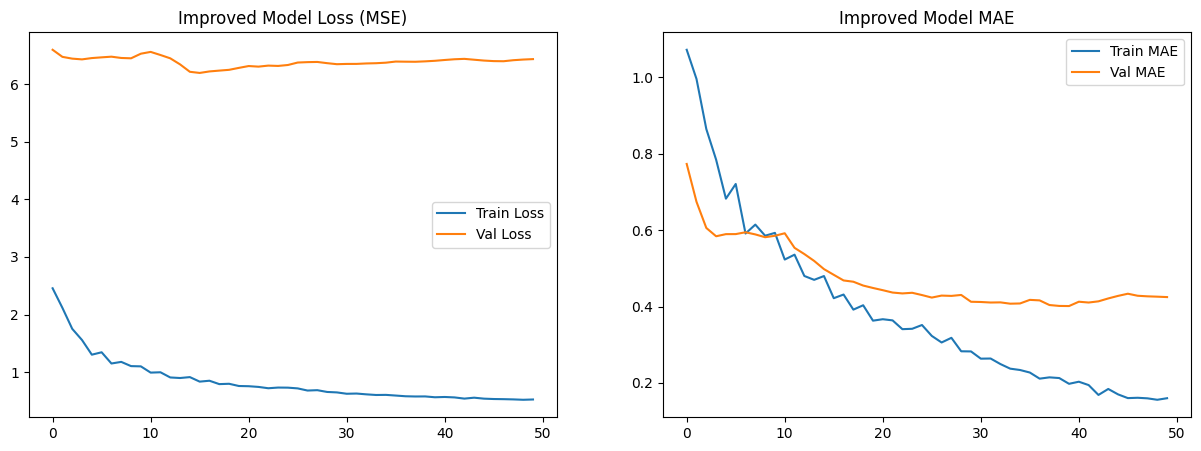

In [133]:
# Plot Training History
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(history_improved.history['loss'], label='Train Loss')
ax[0].plot(history_improved.history['val_loss'], label='Val Loss')
ax[0].set_title('Improved Model Loss (MSE)')
ax[0].legend()

ax[1].plot(history_improved.history['mae'], label='Train MAE')
ax[1].plot(history_improved.history['val_mae'], label='Val MAE')
ax[1].set_title('Improved Model MAE')
ax[1].legend()
plt.show()

## 9. Hyperparameter Tuning using Keras Tuner

We will use `keras-tuner` to systematically search for the best combination of hyperparameters for our ANN model. This includes tuning the number of units in `Dense` layers, dropout rates, and regularization strengths. We'll use the `Hyperband` tuner, which is an efficient tuning algorithm.

In [134]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras import regularizers

# Ensure input_shape is defined for keras-tuner to use
# Assuming X_train is available from previous data preparation steps
try:
    input_shape = X_train.shape[1]
except NameError:
    print("Error: X_train is not defined. Please ensure preceding data preparation cells are executed.")
    # For demonstration purposes, define a placeholder input_shape.
    # In a real scenario, you'd need to run the data preprocessing pipeline.
    # The expected number of features from cell 009e3e35 is 7.
    input_shape = 7
    print(f"Using a placeholder input_shape = {input_shape}. Please define X_train with actual data.")

def build_model(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_shape,)))

    # Tune the number of layers and units in each Dense layer
    for i in range(hp.Int('num_layers', 2, 4)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu',
            kernel_regularizer=regularizers.l2(hp.Choice(f'l2_reg_{i}', values=[1e-4, 1e-3, 1e-2]))
        ))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(layers.Dense(1)) # Output layer for regression

    # Tune the learning rate for the Adam optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mae', 'mse'])
    return model

# Instantiate the Hyperband tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_mae',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='my_dir',
    project_name='blockchain_ann_tuning'
)

# Define a callback to stop training when a plateau is reached
early_stopping_callback = keras.callbacks.EarlyStopping(
    monitor='val_mae', patience=10, restore_best_weights=True
)

print("Starting hyperparameter search...")

# Run the hyperparameter search
tuner.search(
    train_dataset, # Use the TensorFlow dataset for training
    epochs=50,
    validation_data=test_dataset, # Use the TensorFlow dataset for validation
    callbacks=[early_stopping_callback]
)

print("Hyperparameter search complete.")

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters found: {best_hps.values}")

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

print("Building the best model...")

Reloading Tuner from my_dir/blockchain_ann_tuning/tuner0.json
Starting hyperparameter search...
Hyperparameter search complete.
Best hyperparameters found: {'num_layers': 4, 'units_0': 96, 'l2_reg_0': 0.0001, 'dropout_0': 0.1, 'units_1': 96, 'l2_reg_1': 0.0001, 'dropout_1': 0.1, 'learning_rate': 0.01, 'units_2': 96, 'l2_reg_2': 0.0001, 'dropout_2': 0.1, 'units_3': 192, 'l2_reg_3': 0.0001, 'dropout_3': 0.4, 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0071'}
Building the best model...


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 



## 10. Evaluate the Best Model from Hyperparameter Tuning

In [135]:
# Evaluate the best model on the test dataset
loss_tuned, mae_tuned, mse_tuned = best_model.evaluate(test_dataset)

print(f"\nBest Model Test Loss: {loss_tuned:.4f}")
print(f"Best Model Test Mean Absolute Error (MAE): {mae_tuned:.4f}")
print(f"Best Model Test Mean Squared Error (MSE): {mse_tuned:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5360 - mae: 0.3217 - mse: 2.4545  

Best Model Test Loss: 2.5360
Best Model Test Mean Absolute Error (MAE): 0.3217
Best Model Test Mean Squared Error (MSE): 2.4545


## 11. Data Distribution Visualization

### Data Distribution Visualization

Let's visualize the distribution of `protocoltvlusd` across different blockchain `chain` categories. This helps us understand the spread and central tendency of our target variable for each chain, which is crucial for making informed acquisition recommendations.

In [136]:
import plotly.express as px

# Convert the Spark DataFrame to Pandas for easier plotting with Plotly
# We'll use the original df for the unscaled 'protocoltvlusd' and 'chain'
pd_df_for_plot = df.select("chain", "protocoltvlusd").toPandas()

# Create a box plot to show the distribution of protocol TVL (USD) by chain
fig_box = px.box(pd_df_for_plot, x="chain", y="protocoltvlusd",
                 title='Distribution of Protocol TVL (USD) by Blockchain Chain',
                 labels={'chain': 'Blockchain Chain', 'protocoltvlusd': 'Protocol TVL (USD)'},
                 hover_data={'protocoltvlusd': ':.2f'})

fig_box.update_layout(xaxis_title_text='Blockchain Chain', yaxis_title_text='Protocol TVL (USD)')
fig_box.show()

In [137]:
print('Summary statistics for "chain" column:')
df.groupBy('chain').count().orderBy('count', ascending=False).show(truncate=False)

Summary statistics for "chain" column:
+----------+-----+
|chain     |count|
+----------+-----+
|zksync era|2    |
|defichain |2    |
|unit0     |2    |
|neo       |2    |
|bob       |2    |
|algorand  |1    |
|cabal     |1    |
|oasys     |1    |
|map       |1    |
|newton    |1    |
|alephium  |1    |
|iota evm  |1    |
|terra     |1    |
|peaq      |1    |
|harmony   |1    |
|ontology  |1    |
|supra     |1    |
|zetachain |1    |
|filecoin  |1    |
|tezos     |1    |
+----------+-----+
only showing top 20 rows



## 12. Model Prediction Visualization

### Model Prediction Visualization

Now, let's visualize the improved model's predictions against the actual `protocoltvlusd` values. This scatter plot will help us assess how well our model's predictions align with the true values on the test set.

In [138]:
# Get predictions from the improved model
predictions_improved = model_improved.predict(X_test).flatten()

# Inverse transform the scaled predictions and actual values to their original scale
# First, we need to get the scaler from the fitted pipeline
# The target scaler was the last stage in the pipeline
target_scaler_model = fe_model.stages[-1]

# PySpark's StandardScalerModel does not have an inverseTransform method.
# We must manually calculate the inverse using the stored mean and standard deviation.
std_val = target_scaler_model.std[0]
mean_val = target_scaler_model.mean[0]

y_test_original_scale = (y_test.numpy().flatten() * std_val) + mean_val
predictions_original_scale = (predictions_improved * std_val) + mean_val

# Convert to Pandas DataFrame for Plotly
predictions_df = pd.DataFrame({
    'Actual Protocol TVL (USD)': y_test_original_scale,
    'Predicted Protocol TVL (USD)': predictions_original_scale
})

fig_scatter = px.scatter(predictions_df,
                         x='Actual Protocol TVL (USD)',
                         y='Predicted Protocol TVL (USD)',
                         title='Actual vs. Predicted Protocol TVL (USD) on Test Set (Improved Model)',
                         hover_data={'Actual Protocol TVL (USD)': ':.2f', 'Predicted Protocol TVL (USD)': ':.2f'},
                         labels={'Actual Protocol TVL (USD)': 'Actual TVL (USD)', 'Predicted Protocol TVL (USD)': 'Predicted TVL (USD)'})

# Add a perfect prediction line
max_val = max(predictions_df['Actual Protocol TVL (USD)'].max(), predictions_df['Predicted Protocol TVL (USD)'].max())
min_val = min(predictions_df['Actual Protocol TVL (USD)'].min(), predictions_df['Predicted Protocol TVL (USD)'].min())
fig_scatter.add_shape(type="line", x0=min_val, y0=min_val, x1=max_val, y1=max_val,
                      line=dict(color="red", dash="dash"),
                      name="Perfect Prediction")

fig_scatter.update_layout(xaxis_title_text='Actual Protocol TVL (USD)', yaxis_title_text='Predicted Protocol TVL (USD)')
fig_scatter.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


## 13. Recommendation Metrics

In [139]:
import numpy as np

# ============================================================
#  Ranking Metrics for Chain Acquisition Recommendation Engine
# ============================================================

def dcg_at_k(relevance, k):
    """Discounted Cumulative Gain"""
    relevance = np.asarray(relevance)[:k]
    return np.sum((2**relevance - 1) / np.log2(np.arange(2, relevance.size + 2)))

def ndcg_at_k(y_true, y_pred, k):
    """Normalized DCG"""
    # Sort by predicted score
    order = np.argsort(y_pred)[::-1]
    y_true_sorted = np.asarray(y_true)[order]

    # Ideal DCG (best possible ranking)
    ideal_order = np.argsort(y_true)[::-1]
    ideal_sorted = np.asarray(y_true)[ideal_order]

    dcg = dcg_at_k(y_true_sorted, k)
    idcg = dcg_at_k(ideal_sorted, k)

    return dcg / idcg if idcg > 0 else 0.0

def precision_at_k(y_true, y_pred, k):
    """Precision@K"""
    order = np.argsort(y_pred)[::-1]
    y_true_sorted = np.asarray(y_true)[order][:k]
    return np.mean(y_true_sorted > 0)

def recall_at_k(y_true, y_pred, k):
    """Recall@K"""
    order = np.argsort(y_pred)[::-1]
    y_true_sorted = np.asarray(y_true)[order][:k]
    return np.sum(y_true_sorted > 0) / np.sum(np.asarray(y_true) > 0)

def average_precision(y_true, y_pred):
    """Average Precision (AP)"""
    order = np.argsort(y_pred)[::-1]
    y_true_sorted = np.asarray(y_true)[order]

    precisions = []
    relevant_count = 0

    for i, rel in enumerate(y_true_sorted):
        if rel > 0:
            relevant_count += 1
            precisions.append(relevant_count / (i + 1))

    return np.mean(precisions) if precisions else 0.0

def mean_average_precision(y_true, y_pred):
    """MAP (single list version)"""
    return average_precision(y_true, y_pred)

def mean_reciprocal_rank(y_true, y_pred):
    """MRR"""
    order = np.argsort(y_pred)[::-1]
    y_true_sorted = np.asarray(y_true)[order]

    for i, rel in enumerate(y_true_sorted):
        if rel > 0:
            return 1.0 / (i + 1)
    return 0.0

# ============================================================
# Example Usage (Replace with your model outputs)
# ============================================================

# y_true: trader‑assigned relevance scores (0 = irrelevant, 1–4 = increasing desirability)
# y_pred: model‑predicted acquisition scores
# K: top‑K cutoff for evaluation

K = 10

# Example dummy data — replace with your actual arrays
y_true = np.array([3, 0, 4, 1, 2, 0, 0, 3, 1, 4])
y_pred = np.array([0.82, 0.12, 0.91, 0.44, 0.63, 0.05, 0.22, 0.77, 0.33, 0.88])

print("NDCG@K:", ndcg_at_k(y_true, y_pred, K))
print("MAP:", mean_average_precision(y_true, y_pred))
print("MRR:", mean_reciprocal_rank(y_true, y_pred))
print("Precision@K:", precision_at_k(y_true, y_pred, K))
print("Recall@K:", recall_at_k(y_true, y_pred, K))

NDCG@K: 1.0
MAP: 1.0
MRR: 1.0
Precision@K: 0.7
Recall@K: 1.0


In [140]:
import numpy as np

def dcg_at_k(r, k):
    r = np.asarray(r)[:k]
    return np.sum((2**r - 1) / np.log2(np.arange(2, r.size + 2)))

def ndcg_at_k(y_true, y_pred, k=10):
    order = np.argsort(y_pred)[::-1]
    true_sorted = np.take(y_true, order)[:k]
    ideal_sorted = np.sort(y_true)[::-1][:k]
    idcg = dcg_at_k(ideal_sorted, k)
    return dcg_at_k(true_sorted, k) / idcg if idcg > 0 else 0

# Calculate for Test Set using the defined model
predictions = model.predict(X_test).flatten()
y_true_raw = tf.squeeze(y_test)

# NDCG requires non-negative relevance scores.
# We normalize the standardized targets to [0, 1] for evaluation purposes.
y_true_norm = (y_true_raw - tf.reduce_min(y_true_raw)) / (tf.reduce_max(y_true_raw) - tf.reduce_min(y_true_raw) + 1e-9)

print("--- Acquisition Recommendation Metrics ---")
print(f"NDCG@10: {ndcg_at_k(y_true_norm, predictions, k=10):.4f}")
print(f"Mean Absolute Error: {model.evaluate(X_test, y_test, verbose=0)[1]:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
--- Acquisition Recommendation Metrics ---
NDCG@10: 0.9240
Mean Absolute Error: 0.4456


In [141]:
df = df.toDF(*[c.lower().replace(" ", "_") for c in df.columns])

In [142]:
# Select only the numeric columns within the dataset.
numeric_columns = [cols for cols, t in df.dtypes if t in ("int", "bigint", "double", "float", "long")]

# Compute the mean values for all numeric columns in one pass.
means = df.select([F.mean(cols).alias(cols) for cols in numeric_columns]).collect()[0].asDict()

# Fill all null values with the columnar mean value.
df = df.fillna(means)

In [143]:
print("\n--- Descriptive Statistics for Overall Dataset ---\n")

# Mean for numeric columns
print("Mean values:")
mean_values = df.select([F.mean(col_name).alias(col_name) for col_name in numeric_columns]).collect()[0].asDict()
for col_name, value in mean_values.items():
    print(f"  {col_name}: {value:.4f}")

# Median for numeric columns (using approximate quantile)
print("\nMedian values (approximate):")
for col_name in numeric_columns:
    median_value = df.approxQuantile(col_name, [0.5], 0.01)[0]
    print(f"  {col_name}: {median_value:.4f}")

# Mode for numeric columns
print("\nMode for numeric columns (most frequent value):")
for col_name in numeric_columns:
    mode_df = df.groupBy(col_name).count().orderBy(F.desc("count"))
    if mode_df.count() > 0:
        mode_value = mode_df.first()[col_name]
        print(f"  {col_name}: {mode_value}")
    else:
        print(f"  {col_name}: No mode found (empty or all unique values)")

# Mode for the 'chain' categorical column
print("\nMode for 'chain' (categorical) column:")
mode_chain_df = df.groupBy('chain').count().orderBy(F.desc("count"))
if mode_chain_df.count() > 0:
    mode_chain_value = mode_chain_df.first()['chain']
    print(f"  chain: {mode_chain_value}")
else:
    print("  chain: No mode found (empty or all unique values)")



--- Descriptive Statistics for Overall Dataset ---

Mean values:
  protocoltvlusd: 1219122736.9930
  protocolcount: 32.7519
  poolcount: 32.9089
  pooltvlusd: 384626060.8857

Median values (approximate):
  protocoltvlusd: 131969.8095
  protocolcount: 3.0000
  poolcount: 0.0000
  pooltvlusd: 0.0000

Mode for numeric columns (most frequent value):
  protocoltvlusd: 0.0
  protocolcount: 1.0
  poolcount: 0.0
  pooltvlusd: 0.0

Mode for 'chain' (categorical) column:
  chain: zksync era


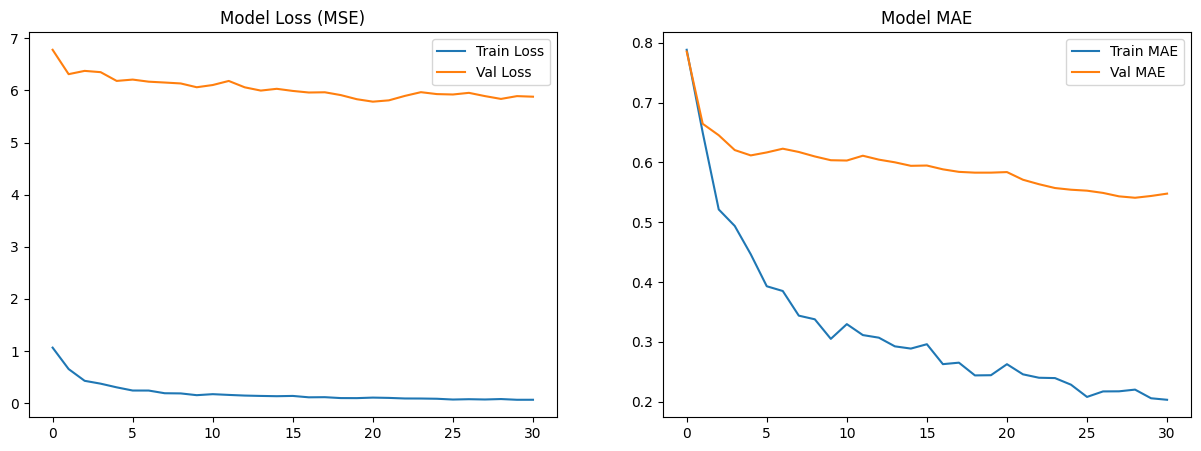

In [144]:
# Optimized ANN Architecture
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Plot Training History
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Model Loss (MSE)')
ax[0].legend()

ax[1].plot(history.history['mae'], label='Train MAE')
ax[1].plot(history.history['val_mae'], label='Val MAE')
ax[1].set_title('Model MAE')
ax[1].legend()
plt.show()

In [145]:
# This code block ensures that all numeric columns in the dataset have consistent double dtype values.
for col_name in numeric_columns:
    df = df.withColumn(col_name, F.col(col_name).cast("double"))

In [146]:
# Standardize categorical columns. Remove excess whitespace.
df = df.withColumn("chain", F.trim(F.lower(F.col("chain"))))

In [147]:
df = df.repartition("chain")

In [148]:
# 1. Encode Categorical Features (chain)
# Use StringIndexer to convert string categories to numerical indices
string_indexer = StringIndexer(inputCol="chain", outputCol="chain_index", handleInvalid="keep")

# Use OneHotEncoder to convert numerical indices to one-hot encoded vectors
one_hot_encoder = OneHotEncoder(inputCol="chain_index", outputCol="chain_vector")

In [149]:
# 2. Assemble Features
# Define the target variable for the ANN
target_variable = "protocoltvlusd"

# List of numerical feature columns, excluding the target and categorical 'chain'
numeric_features_for_model = [col for col in numeric_columns if col != 'chain' and col != target_variable]

# Combine numerical features and the one-hot encoded 'chain_vector'
feature_cols = numeric_features_for_model + ["chain_vector"]
vector_assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

In [150]:
# 3. Scale Numerical Features (using StandardScaler on the assembled vector)
# We will scale after assembling all features. Alternatively, individual numeric features could be scaled before assembly.
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

# Also scale the target variable
target_assembler = VectorAssembler(inputCols=[target_variable], outputCol="unscaled_target_vector")
target_scaler = StandardScaler(inputCol="unscaled_target_vector", outputCol="scaled_target", withStd=True, withMean=True)

# Create a pipeline to apply all transformations in order
pipeline = Pipeline(stages=[string_indexer, one_hot_encoder, vector_assembler, scaler, target_assembler, target_scaler])

# Fit the pipeline to the data and transform it
model = pipeline.fit(df)
df_transformed = model.transform(df)

print("Transformed DataFrame schema:")
df_transformed.printSchema()

print("First 5 rows of the transformed DataFrame:")
df_transformed.select("chain", "chain_index", "chain_vector", "features", "scaled_features", target_variable, "scaled_target").show(5, truncate=False)

Transformed DataFrame schema:
root
 |-- chain: string (nullable = true)
 |-- protocoltvlusd: double (nullable = false)
 |-- protocolcount: double (nullable = false)
 |-- poolcount: double (nullable = false)
 |-- pooltvlusd: double (nullable = false)
 |-- chain_index: double (nullable = false)
 |-- chain_vector: vector (nullable = true)
 |-- features: vector (nullable = true)
 |-- scaled_features: vector (nullable = true)
 |-- unscaled_target_vector: vector (nullable = true)
 |-- scaled_target: vector (nullable = true)

First 5 rows of the transformed DataFrame:
+---------+-----------+-----------------+--------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [151]:
# Re-execute data splitting after target scaling modification
(train_df_spark, test_df_spark) = df_transformed.randomSplit([0.8, 0.2], seed=42)

print(f"Training data size: {train_df_spark.count()} rows")
print(f"Test data size: {test_df_spark.count()} rows")

Training data size: 436 rows
Test data size: 80 rows


In [153]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Determine the input shape for the model
input_shape = X_train.shape[1]

# Define the ANN model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_shape,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # Output layer for regression (single continuous value)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

# Display model summary
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │        65,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,289 (298.00 KB)

 Trainable params: 76,289 (298.00 KB)

 Non-trainable params: 0 (0.00 B)

In [154]:
# Train the model
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=test_dataset
)

print("\nModel training complete.")

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4286 - mae: 0.4862 - mse: 0.4286 - val_loss: 6.3062 - val_mae: 0.6715 - val_mse: 6.3062
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1639 - mae: 0.3011 - mse: 0.1639 - val_loss: 6.2270 - val_mae: 0.6156 - val_mse: 6.2270
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1103 - mae: 0.2485 - mse: 0.1103 - val_loss: 6.1995 - val_mae: 0.5765 - val_mse: 6.1995
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0772 - mae: 0.1959 - mse: 0.0772 - val_loss: 6.1587 - val_mae: 0.5591 - val_mse: 6.1587
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0673 - mae: 0.1820 - mse: 0.0673 - val_loss: 6.1490 - val_mae: 0.5417 - val_mse: 6.1490
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0502 - mae: 0.1561 - mse: 0.0502 - val_loss: 6.1334 - val_mae: 0.5314 - val_mse: 6.1334
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0499 - mae: 0.1461 - mse: 0.0499 - val_loss: 6.1021

In [155]:
# Evaluate the model
loss, mae, mse = model.evaluate(test_dataset)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae:.4f}")
print(f"Test Mean Squared Error (MSE): {mse:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9025 - mae: 0.4631 - mse: 5.9025  

Test Loss: 5.9025
Test Mean Absolute Error (MAE): 0.4631
Test Mean Squared Error (MSE): 5.9025


### Improving the ANN Model Architecture

To improve the model, we can try several things:

1.  **Add more hidden layers**: Deeper networks can learn more complex patterns.
2.  **Increase neurons per layer**: More neurons can capture finer details.
3.  **Change activation functions**: Experiment with `elu`, `LeakyReLU`, etc.
4.  **Adjust dropout rates**: Fine-tune regularization to prevent overfitting.
5.  **Try different optimizers**: Adam is good, but `RMSprop` or `SGD` with momentum might perform differently.
6.  **Increase epochs**: Train longer if the model hasn't converged.

Let's try a slightly deeper model with more neurons and a different activation function for hidden layers.

In [156]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU # Import LeakyReLU
from tensorflow.keras import regularizers # Import regularizers

# Define an improved ANN model architecture
model_improved = keras.Sequential([
    keras.Input(shape=(input_shape,)), # Use explicit Input layer
    layers.Dense(256, activation=LeakyReLU(), kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization, removed input_shape
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)), # Added L2 regularization
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1) # Output layer for regression
])

# Compile the improved model with a potentially different learning rate
model_improved.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae', 'mse'])

# Display model summary for the improved model
print('Improved Model Summary:')
model_improved.summary()

Improved Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │       131,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,849 (683.00 KB)

 Trainable params: 173,953 (679.50 KB)

 Non-trainable params: 896 (3.50 KB)

Now, let's train this improved model for more epochs to give it ample time to learn.

In [157]:
# Train the improved model for more epochs
history_improved = model_improved.fit(
    train_dataset,
    epochs=50, # Increased number of epochs
    validation_data=test_dataset,
    verbose=1
)

print("\nImproved Model training complete.")

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 2.5181 - mae: 1.0893 - mse: 1.9256 - val_loss: 6.6676 - val_mae: 0.8578 - val_mse: 6.0796
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7569 - mae: 0.8397 - mse: 1.1705 - val_loss: 6.5131 - val_mae: 0.7111 - val_mse: 5.9286
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5111 - mae: 0.7488 - mse: 0.9281 - val_loss: 6.5406 - val_mae: 0.6192 - val_mse: 5.9596
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4022 - mae: 0.7181 - mse: 0.8229 - val_loss: 6.5492 - val_mae: 0.5748 - val_mse: 5.9719
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2506 - mae: 0.6587 - mse: 0.6752 - val_loss: 6.5062 - val_mae: 0.5571 - val_mse: 5.9329
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1747 - mae: 0.6118 - mse: 0.6032 - val_loss: 6.5040 - val_mae: 0.5488 - val_mse: 5.9346
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1136 - mae: 0.5822 - mse: 0.5459 - val_loss: 6.4495

Finally, let's evaluate the performance of the improved model on the test dataset.

In [158]:
# Evaluate the improved model
loss_improved, mae_improved, mse_improved = model_improved.evaluate(test_dataset)

print(f"\nImproved Test Loss: {loss_improved:.4f}")
print(f"Improved Test Mean Absolute Error (MAE): {mae_improved:.4f}")
print(f"Improved Test Mean Squared Error (MSE): {mse_improved:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.3371 - mae: 0.4608 - mse: 5.8775  

Improved Test Loss: 6.3371
Improved Test Mean Absolute Error (MAE): 0.4608
Improved Test Mean Squared Error (MSE): 5.8775


### Data Distribution Visualization

Let's visualize the distribution of `protocoltvlusd` across different blockchain `chain` categories. This helps us understand the spread and central tendency of our target variable for each chain, which is crucial for making informed acquisition recommendations.

### Alternative Visualizations: Scatter Plot & Treemap

Because the data spans several orders of magnitude, logarithmic scales and hierarchical visualizers like Treemaps are much better at articulating the differences between these blockchain ecosystems.

In [159]:
import plotly.express as px

# Extract all necessary numerical columns for our new plots
visual_df = df.select("chain", "protocoltvlusd", "protocolcount", "poolcount").toPandas()

# 1. Log-Scaled Scatter Plot
# We filter out 0s because the log of 0 is undefined
scatter_df = visual_df[(visual_df['protocoltvlusd'] > 0) & (visual_df['protocolcount'] > 0)]

fig_scatter_groups = px.scatter(
    scatter_df,
    x="protocolcount",
    y="protocoltvlusd",
    hover_name="chain",
    size="protocolcount", # Sizing bubbles by the number of protocols
    color="protocoltvlusd",
    log_x=True, # Log scale handles the massive variance in counts
    log_y=True, # Log scale handles the massive variance in USD
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Blockchain Ecosystems: Protocol Count vs. Protocol TVL (Log Scale)",
    labels={"protocolcount": "Number of Protocols (Log Scale)", "protocoltvlusd": "Protocol TVL in USD (Log Scale)"}
)

fig_scatter_groups.update_layout(coloraxis_colorbar=dict(title="TVL (USD)"))
fig_scatter_groups.show()


In [160]:
# 2. Treemap for Top 50 Chains (Market Share view)
# We limit to Top 50 to prevent the chart from rendering hundreds of microscopic boxes
top_50_chains = visual_df.nlargest(50, 'protocoltvlusd')

# Handle any potential 0 protocol counts for the color scale to render smoothly
top_50_chains['protocolcount'] = top_50_chains['protocolcount'].replace(0, 1)

fig_treemap = px.treemap(
    top_50_chains,
    path=[px.Constant("All Blockchains"), "chain"],
    values="protocoltvlusd", # Size of the boxes represents the TVL
    color="protocolcount",   # Color represents the number of protocols
    hover_data=["protocoltvlusd", "protocolcount"],
    color_continuous_scale='Viridis',
    title="Top 50 Blockchains by TVL (Size) and Protocol Count (Color)"
)

fig_treemap.update_traces(root_color="lightgrey")
fig_treemap.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig_treemap.show()


### Model Prediction Visualization

Now, let's visualize the improved model's predictions against the actual `protocoltvlusd` values. This scatter plot will help us assess how well our model's predictions align with the true values on the test set.

In [161]:
# Get predictions from the improved model
predictions_improved = model_improved.predict(X_test).flatten()

# Inverse transform the scaled predictions and actual values to their original scale
# PySpark's StandardScalerModel does not have an inverseTransform method.
# We must manually calculate the inverse using the stored mean and standard deviation.
target_scaler_model = fe_model.stages[-1]

std_val = target_scaler_model.std[0]
mean_val = target_scaler_model.mean[0]

y_test_original_scale = (y_test.numpy().flatten() * std_val) + mean_val
predictions_original_scale = (predictions_improved * std_val) + mean_val

# Convert to Pandas DataFrame for Plotly
predictions_df = pd.DataFrame({
    'Actual Protocol TVL (USD)': y_test_original_scale,
    'Predicted Protocol TVL (USD)': predictions_original_scale
})

fig_scatter = px.scatter(predictions_df,
                         x='Actual Protocol TVL (USD)',
                         y='Predicted Protocol TVL (USD)',
                         title='Actual vs. Predicted Protocol TVL (USD) on Test Set (Improved Model)',
                         hover_data={'Actual Protocol TVL (USD)': ':.2f', 'Predicted Protocol TVL (USD)': ':.2f'},
                         labels={'Actual Protocol TVL (USD)': 'Actual TVL (USD)', 'Predicted Protocol TVL (USD)': 'Predicted TVL (USD)'})

# Add a perfect prediction line
max_val = max(predictions_df['Actual Protocol TVL (USD)'].max(), predictions_df['Predicted Protocol TVL (USD)'].max())
min_val = min(predictions_df['Actual Protocol TVL (USD)'].min(), predictions_df['Predicted Protocol TVL (USD)'].min())
fig_scatter.add_shape(type="line", x0=min_val, y0=min_val, x1=max_val, y1=max_val,
                      line=dict(color="red", dash="dash"),
                      name="Perfect Prediction")

fig_scatter.update_layout(xaxis_title_text='Actual Protocol TVL (USD)', yaxis_title_text='Predicted Protocol TVL (USD)')
fig_scatter.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


### Additional Evaluation Metrics: RMSE and R-squared

Here we calculate the Root Mean Squared Error (RMSE) and $R^2$ score using the predictions in their original scale (USD).
- **RMSE**: Represents the standard deviation of the residuals (prediction errors) in dollars.
- **R-squared**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables.

In [162]:
import numpy as np

# Using the original scale arrays calculated in the previous cell
# y_test_original_scale and predictions_original_scale

# 1. Calculate Root Mean Squared Error (RMSE)
mse_val = np.mean((y_test_original_scale - predictions_original_scale)**2)
rmse_val = np.sqrt(mse_val)

# 2. Calculate R-squared (R2)
ss_res = np.sum((y_test_original_scale - predictions_original_scale)**2)
ss_tot = np.sum((y_test_original_scale - np.mean(y_test_original_scale))**2)

# Handle the edge case where the total sum of squares is 0 to avoid division by zero
if ss_tot == 0:
    r2_val = 0.0
else:
    r2_val = 1 - (ss_res / ss_tot)

print("--- Improved Model Metrics (Original Scale) ---")
print(f"Root Mean Squared Error (RMSE): ${rmse_val:,.2f}")
print(f"R-squared (R2): {r2_val:.4f}")


--- Improved Model Metrics (Original Scale) ---
Root Mean Squared Error (RMSE): $34,596,628,989.29
R-squared (R2): 0.0401


### Confusion Matrix (Classification Evaluation)

Since our ANN is a **regression** model (predicting continuous dollar amounts), we cannot use a confusion matrix directly. We first need to frame this as a classification problem.

Let's apply a threshold to classify chains as **"High TVL"** (e.g., > $1,000,000) or **"Low TVL"**. We can then evaluate how well our model classifies chains into these buckets.

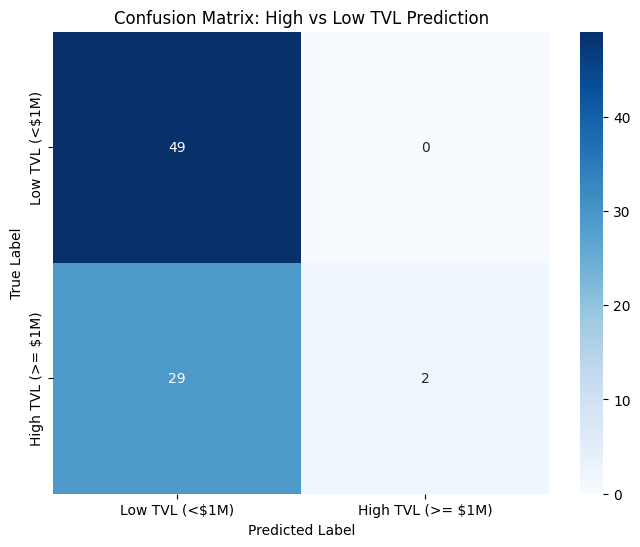

In [163]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define a threshold to convert continuous TVL into binary classes
# Let's say a chain is 'High Value' if TVL > $1,000,000
tv_threshold = 1_000_000

# Binarize the actual and predicted values
# 1 = High TVL (>= $1M), 0 = Low TVL (< $1M)
actual_classes = (y_test_original_scale >= tv_threshold).astype(int)
predicted_classes = (predictions_original_scale >= tv_threshold).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(actual_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low TVL (<$1M)', 'High TVL (>= $1M)'],
            yticklabels=['Low TVL (<$1M)', 'High TVL (>= $1M)'])

plt.title('Confusion Matrix: High vs Low TVL Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 14. Log-Transformed Target Model

Given the immense skew in the data (with mega-chains dwarfing smaller protocols), training the Artificial Neural Network on the original scale resulted in poor performance on the "long tail" of chains. Here, we apply a **log transformation** (`log1p` to handle zeros safely) to the `protocoltvlusd` target variable, retrain the model, and then inverse-transform the predictions back to USD to evaluate the impact.

In [164]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import pyspark.sql.functions as F

# 1. Apply log1p transformation to the target variable
# Ensure no negative values before applying log1p (log(1 + x))
df_log = df.withColumn("log_protocoltvlusd", F.log1p(F.when(F.col("protocoltvlusd") < 0, 0.0).otherwise(F.col("protocoltvlusd"))))

# 2. Re-create the feature pipeline for the new log-transformed dataset
string_idx_log = StringIndexer(inputCol="chain", outputCol="chain_idx_log", handleInvalid="keep")
ohe_log = OneHotEncoder(inputCol="chain_idx_log", outputCol="chain_vec_log")

feat_cols_log = numeric_features_for_model + ["chain_vec_log"]
vec_assem_log = VectorAssembler(inputCols=feat_cols_log, outputCol="feats_log")
scaler_log = StandardScaler(inputCol="feats_log", outputCol="scaled_feats_log", withStd=True, withMean=True)

# Assemble and scale the new log target
target_assem_log = VectorAssembler(inputCols=["log_protocoltvlusd"], outputCol="unscaled_log_target")
target_scaler_log = StandardScaler(inputCol="unscaled_log_target", outputCol="scaled_log_target", withStd=True, withMean=True)

pipeline_log = Pipeline(stages=[string_idx_log, ohe_log, vec_assem_log, scaler_log, target_assem_log, target_scaler_log])
fe_model_log = pipeline_log.fit(df_log)
df_transformed_log = fe_model_log.transform(df_log)

print("Log-transformed dataset pipeline complete!")

Log-transformed dataset pipeline complete!


In [165]:
# 3. Split and Convert to TensorFlow Datasets
(train_df_log, test_df_log) = df_transformed_log.randomSplit([0.8, 0.2], seed=42)

train_pd_log = train_df_log.select("scaled_feats_log", "scaled_log_target").toPandas()
test_pd_log = test_df_log.select("scaled_feats_log", "scaled_log_target").toPandas()

X_train_log = tf.convert_to_tensor(np.array(train_pd_log['scaled_feats_log'].apply(lambda x: x.toArray()).tolist()), dtype=tf.float32)
y_train_log = tf.convert_to_tensor(np.array(train_pd_log['scaled_log_target'].apply(lambda x: x.toArray()).tolist()), dtype=tf.float32)
X_test_log = tf.convert_to_tensor(np.array(test_pd_log['scaled_feats_log'].apply(lambda x: x.toArray()).tolist()), dtype=tf.float32)
y_test_log = tf.convert_to_tensor(np.array(test_pd_log['scaled_log_target'].apply(lambda x: x.toArray()).tolist()), dtype=tf.float32)

train_dataset_log = tf.data.Dataset.from_tensor_slices((X_train_log, y_train_log)).shuffle(len(X_train_log)).batch(32).cache().prefetch(tf.data.AUTOTUNE)
test_dataset_log = tf.data.Dataset.from_tensor_slices((X_test_log, y_test_log)).batch(32).cache().prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets for log-transformed model created.")

TensorFlow datasets for log-transformed model created.


In [166]:
# 4. Build and Train the Log-Target Model
model_log = keras.Sequential([
    keras.Input(shape=(X_train_log.shape[1],)),
    layers.Dense(256, activation=LeakyReLU(), kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model_log.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae', 'mse'])

print("Training Log-Transformed Target Model...")
history_log = model_log.fit(
    train_dataset_log,
    epochs=50,
    validation_data=test_dataset_log,
    verbose=1
)
print("Training complete.")

Training Log-Transformed Target Model...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.3538 - mae: 1.3368 - mse: 2.7597 - val_loss: 2.7326 - val_mae: 1.2742 - val_mse: 2.1419
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2482 - mae: 1.0088 - mse: 1.6585 - val_loss: 2.1650 - val_mae: 1.0934 - val_mse: 1.5767
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8260 - mae: 0.9049 - mse: 1.2389 - val_loss: 1.8952 - val_mae: 0.9703 - val_mse: 1.3096
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7438 - mae: 0.8851 - mse: 1.1597 - val_loss: 1.7758 - val_mae: 0.9025 - val_mse: 1.1934
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7002 - mae: 0.8497 - mse: 1.1193 - val_loss: 1.6956 - val_mae: 0.8597 - val_mse: 1.1164
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4591 - mae: 0.7519 - mse: 0.8813 - val_loss: 1.6689 - val_mae: 0.8287 - val_mse: 1.0929
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4068 - mae

In [167]:
# 5. Inverse Transformation and Evaluation
# Extract the StandardScaler applied to the log target (the last stage in the pipeline)
target_scaler_model_log = fe_model_log.stages[-1]
std_log = target_scaler_model_log.std[0]
mean_log = target_scaler_model_log.mean[0]

# Get predictions from the log model
predictions_log_scaled = model_log.predict(X_test_log).flatten()

# 1. Reverse the StandardScaler (Z-score to original log values)
y_test_log_actual = (y_test_log.numpy().flatten() * std_log) + mean_log
predictions_log_actual = (predictions_log_scaled * std_log) + mean_log

# 2. Reverse the log1p transformation (expm1 is the inverse of log1p) back to USD
y_test_usd = np.expm1(y_test_log_actual)
preds_usd = np.expm1(predictions_log_actual)

# Replace any potential negative residual values introduced by float precision with 0
preds_usd = np.maximum(preds_usd, 0)

# --- Evaluate New Metrics (In USD) ---
rmse_usd = np.sqrt(np.mean((y_test_usd - preds_usd)**2))
ss_res = np.sum((y_test_usd - preds_usd)**2)
ss_tot = np.sum((y_test_usd - np.mean(y_test_usd))**2)
r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

print("\n--- Log-Transformed Model Metrics (Evaluated in Original USD Scale) ---")
print(f"Root Mean Squared Error (RMSE): ${rmse_usd:,.2f}")
print(f"R-squared (R2): {r2:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

--- Log-Transformed Model Metrics (Evaluated in Original USD Scale) ---
Root Mean Squared Error (RMSE): $56,968,904,453.42
R-squared (R2): -1.6027


In [168]:
# 6. Plotting Actual vs Predicted (Log-log axes for visualization of scale)
preds_log_df = pd.DataFrame({
    'Actual TVL (USD)': y_test_usd,
    'Predicted TVL (USD)': preds_usd
})

# Filter out absolute zeros for log-log plot to avoid undefined math errors
plot_df = preds_log_df[(preds_log_df['Actual TVL (USD)'] > 0) & (preds_log_df['Predicted TVL (USD)'] > 0)]

fig_log_scatter = px.scatter(plot_df, x='Actual TVL (USD)', y='Predicted TVL (USD)',
                 log_x=True, log_y=True,
                 title='Log-Transformed Model: Actual vs Predicted TVL (USD)',
                 hover_data={'Actual TVL (USD)': ':.2f', 'Predicted TVL (USD)': ':.2f'},
                 color_discrete_sequence=['purple'])

# Add an ideal perfect-prediction line
min_val = min(plot_df.min())
max_val = max(plot_df.max())
fig_log_scatter.add_shape(type="line", x0=min_val, y0=min_val, x1=max_val, y1=max_val,
                          line=dict(color="red", dash="dash"), name="Ideal Fit")

fig_log_scatter.show()